# 02 · Emotion Classification on RAVDESS

**Goal:** Verify wav2vec2-based emotion classification works on the same RAVDESS clips we already ran prosody on.

Two complementary heads from `backend/pipeline/emotion.py`:

1. **Categorical** — `superb/wav2vec2-base-superb-er`. Trained on IEMOCAP, outputs one of `{ang, hap, neu, sad}`.
2. **Dimensional** — `audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim`. Trained on MSP-Podcast, regression head outputs continuous valence × arousal × dominance.

**Why both?** Categorical gives a clean label; dimensional gives a *continuous point on Russell's circumplex* — that's the differentiator from existing emotion-tag captioning systems (per `docs/01_DIFFERENTIATION.md`).

**What we check:**
- Confusion matrix of categorical predictions vs. ground-truth (RAVDESS collapsed to 4 classes).
- Per-RAVDESS-emotion accuracy bar chart.
- V/A scatter from the dimensional model, colored by ground truth — does it recover Russell's quadrants?

## 0 · Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

from backend.pipeline.emotion import classify_emotion
from backend.pipeline.datasets import load_ravdess_clips

sns.set_theme(style="whitegrid", context="notebook")
RAVDESS_ROOT = PROJECT_ROOT / "data" / "datasets" / "RAVDESS"
print(f"RAVDESS root: {RAVDESS_ROOT}")

RAVDESS root: /Users/birdhouse/Documents/GitHub/SoundShape/data/datasets/RAVDESS


## 1 · Run dual classifier on all 120 clips

First run downloads ~1.2 GB (audeering model) + uses the already-cached `superb` model. After that it's ~2 clips/sec on Apple Silicon CPU.

In [2]:
clips = load_ravdess_clips(RAVDESS_ROOT)
print(f"Classifying {len(clips)} clips…")

rows = []
for i, clip in enumerate(clips, start=1):
    r = classify_emotion(str(clip.path))
    rows.append({
        "actor": clip.actor,
        "sex": clip.actor_sex,
        "true_emotion": clip.emotion,
        "intensity": clip.intensity,
        "pred_category": r.category,
        "pred_confidence": r.category_confidence,
        "pred_valence": r.valence,
        "pred_arousal": r.arousal,
        "pred_dominance": r.dominance,
    })
    if i % 20 == 0:
        print(f"  {i}/{len(clips)} processed")

df = pd.DataFrame(rows)
print(f"\nResult matrix: {df.shape}")
df.head()

Classifying 120 clips…


Loading weights:   0%|          | 0/216 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/234 [00:00<?, ?it/s]

  20/120 processed


  40/120 processed


  60/120 processed


  80/120 processed


  100/120 processed


  120/120 processed

Result matrix: (120, 9)


,actor,sex,true_emotion,intensity,pred_category,pred_confidence,pred_valence,pred_arousal,pred_dominance
0,01,male,neutral,normal,neu,0.585167,-0.343684,-0.121716,0.049927
1,01,male,neutral,normal,neu,0.540685,-0.401384,-0.128040,0.039720
2,01,male,neutral,normal,neu,0.921735,-0.309475,-0.217461,-0.003677
3,01,male,neutral,normal,neu,0.484975,-0.368183,-0.237552,-0.023233
4,01,male,calm,normal,neu,0.453328,-0.300482,-0.101339,0.069870


## 2 · Map RAVDESS labels onto the 4-class categorical space

RAVDESS has 8 emotions; the categorical model only has 4. We collapse RAVDESS's labels into the closest of the 4 classes for evaluation. This is intentionally rough — disgust → ang is a loose match — and that's what makes the confusion matrix interesting.

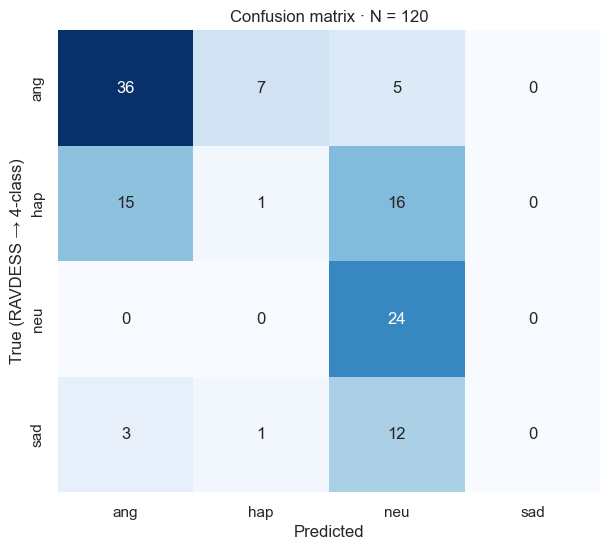


Overall 4-class accuracy: 50.8%

Per-class classification report:
              precision    recall  f1-score   support

         ang       0.67      0.75      0.71        48
         hap       0.11      0.03      0.05        32
         neu       0.42      1.00      0.59        24
         sad       0.00      0.00      0.00        16

    accuracy                           0.51       120
   macro avg       0.30      0.45      0.34       120
weighted avg       0.38      0.51      0.41       120



In [3]:
RAVDESS_TO_4CLASS = {
    "neutral":   "neu",
    "calm":      "neu",
    "happy":     "hap",
    "surprised": "hap",
    "sad":       "sad",
    "angry":     "ang",
    "fearful":   "ang",
    "disgust":   "ang",
}
df["true_4class"] = df["true_emotion"].map(RAVDESS_TO_4CLASS)

classes = ["ang", "hap", "neu", "sad"]
cm = confusion_matrix(df["true_4class"], df["pred_category"], labels=classes)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=classes, yticklabels=classes, cbar=False, ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True (RAVDESS → 4-class)")
ax.set_title(f"Confusion matrix · N = {len(df)}")
plt.show()

accuracy = (df["true_4class"] == df["pred_category"]).mean()
print(f"\nOverall 4-class accuracy: {accuracy:.1%}")
print("\nPer-class classification report:")
print(classification_report(df["true_4class"], df["pred_category"], labels=classes, zero_division=0))

## 3 · Per-RAVDESS-emotion accuracy

How often does each RAVDESS label collapse to its mapped 4-class bucket?

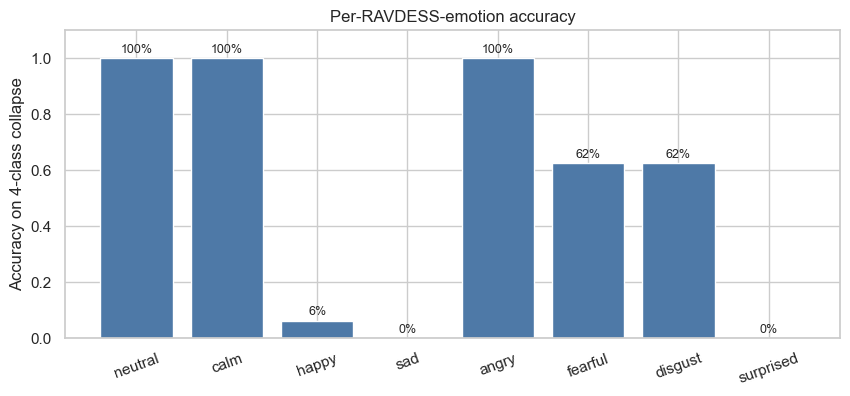

In [4]:
ravdess_order = [
    "neutral", "calm", "happy", "sad",
    "angry", "fearful", "disgust", "surprised",
]
per_emo = (
    df.assign(correct=(df["true_4class"] == df["pred_category"]).astype(int))
    .groupby("true_emotion")["correct"].mean()
    .reindex(ravdess_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(per_emo.index, per_emo.values, color="#4e79a7")
for bar, val in zip(bars, per_emo.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.0%}",
            ha="center", fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Accuracy on 4-class collapse")
ax.set_title("Per-RAVDESS-emotion accuracy")
ax.tick_params(axis="x", rotation=20)
plt.show()

## 4 · V/A scatter from the dimensional model

Each dot is a single RAVDESS clip placed at audeering's predicted (valence, arousal) coordinates. If the dimensional model is doing real work, we expect:

```
                arousal ↑
    angry / fearful  |  happy / surprised
  ─────────────────────────────────── valence →
       sad           |    calm / neutral
                arousal ↓
```


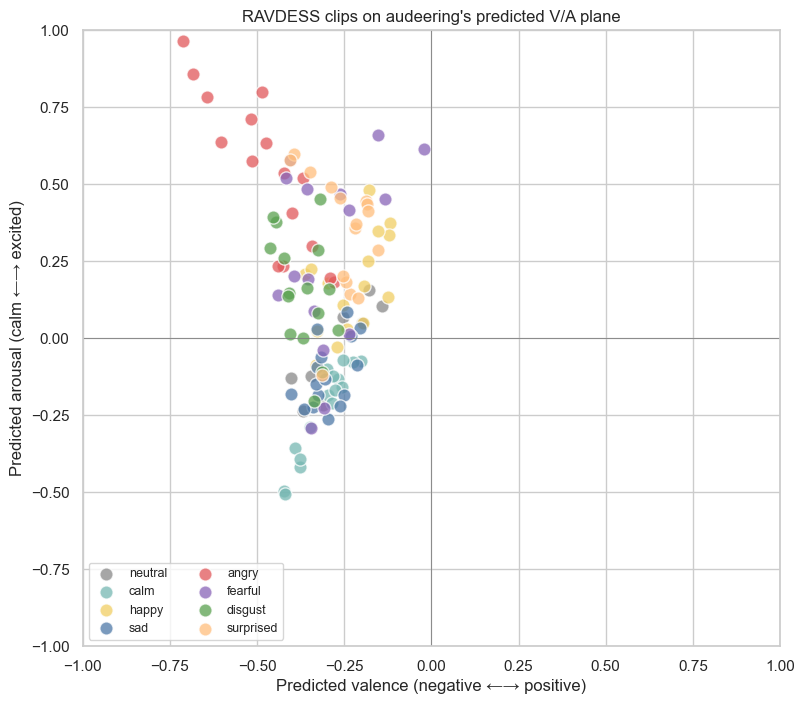

In [5]:
emotion_color = {
    "neutral":   "#888888", "calm":      "#76b7b2",
    "happy":     "#f1ce63", "surprised": "#ffbe7d",
    "sad":       "#4e79a7", "angry":     "#e15759",
    "fearful":   "#8964b8", "disgust":   "#59a14f",
}

fig, ax = plt.subplots(figsize=(9, 8))
for emo in ravdess_order:
    sub = df[df["true_emotion"] == emo]
    ax.scatter(
        sub["pred_valence"], sub["pred_arousal"],
        c=emotion_color[emo], s=90, alpha=0.75,
        edgecolor="white", linewidth=1, label=emo,
    )
ax.axhline(0, color="gray", lw=0.6)
ax.axvline(0, color="gray", lw=0.6)
ax.set_xlabel("Predicted valence (negative ←→ positive)")
ax.set_ylabel("Predicted arousal (calm ←→ excited)")
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_title("RAVDESS clips on audeering's predicted V/A plane")
ax.legend(loc="lower left", fontsize=9, frameon=True, ncols=2)
plt.show()

## 5 · Persist predictions

In [6]:
out_path = PROJECT_ROOT / "data" / "timelines" / "ravdess_emotion_predictions.csv"
df.to_csv(out_path, index=False)
print(f"Wrote {out_path.relative_to(PROJECT_ROOT)} — {df.shape[0]} rows × {df.shape[1]} cols")

Wrote data/timelines/ravdess_emotion_predictions.csv — 120 rows × 10 cols


## 6 · What good looks like

Phase 3 exit criterion (per `docs/04_ROADMAP.md`): *4-class accuracy ≥ 70% on a clean dataset like RAVDESS.*

Note that this is the *English* model on *English* speech. Korean is deferred to Phase 3.5 — we'll either fine-tune on AIHub data or fall back to category→V/A lookup with the prosody-only signal.